<a href="https://colab.research.google.com/github/mythicalharshit/Deep-Learning/blob/main/EXP_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 19: GAN for Generating Handwritten Digits using MNIST

**Objective:** Build and train a Generative Adversarial Network (GAN) to generate handwritten digit images using the MNIST dataset.

**Language:** Python  
**Estimated Time:** 2 hours  
**Libraries Used:** NumPy, Matplotlib, TensorFlow / Keras


## 1. Introduction

A **Generative Adversarial Network (GAN)** consists of two neural networks:

- **Generator:** Creates fake images from random noise.
- **Discriminator:** Tries to distinguish real images from fake images.

Both networks compete with each other during training. Over time, the generator learns to create images that look more like real handwritten digits.


## 2. Aim of the Experiment

In this notebook, we will:

1. Load and preprocess the MNIST dataset
2. Build the generator model
3. Build the discriminator model
4. Combine them into a GAN
5. Train the GAN
6. Generate handwritten digit images
7. Visualize training progress and generated outputs


In [1]:
# Install if needed
# !pip install tensorflow matplotlib numpy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Reshape, Flatten, LeakyReLU, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

## 3. Load and Preprocess MNIST Dataset

MNIST contains 28x28 grayscale images of handwritten digits from 0 to 9. We normalize pixel values to the range **[-1, 1]** because the generator uses `tanh` activation in the output layer.


In [3]:
(x_train, _), (_, _) = mnist.load_data()

x_train = x_train.astype('float32')
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

print('Training data shape:', x_train.shape)
print('Pixel range:', x_train.min(), 'to', x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Pixel range: -1.0 to 1.0


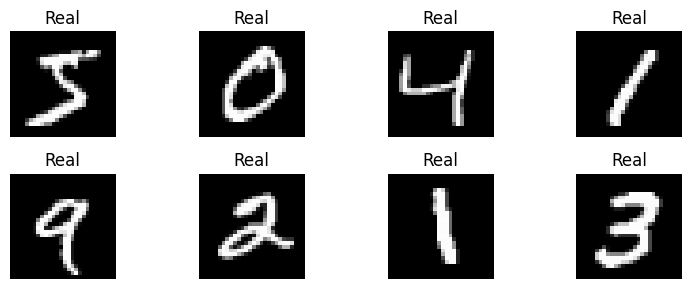

In [4]:
plt.figure(figsize=(8, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title('Real')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Define Hyperparameters


In [5]:
latent_dim = 100
img_rows = 28
img_cols = 28
channels = 1
img_shape = (img_rows, img_cols, channels)

batch_size = 128
epochs = 3000
sample_interval = 500

## 5. Build the Generator

The generator converts a random noise vector into a 28x28 image.


In [7]:
def build_generator(latent_dim):
    model = Sequential(name='Generator')
    model.add(Input(shape=(latent_dim,)))
    model.add(Dense(256))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(1024))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(int(np.prod(img_shape)), activation='tanh'))
    model.add(Reshape(img_shape))
    return model

generator = build_generator(latent_dim)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 3,584 (14.00 KB)

## 6. Build the Discriminator

The discriminator receives an image and predicts whether it is real or fake.


In [8]:
def build_discriminator(img_shape):
    model = Sequential(name='Discriminator')
    model.add(Input(shape=img_shape))
    model.add(Flatten())
    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))
    model.add(Dense(256))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    return model

discriminator = build_discriminator(img_shape)
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5), metrics=['accuracy'])
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Build the Combined GAN Model

The discriminator is frozen while training the combined GAN so that only the generator learns to fool it.


In [9]:
z = Input(shape=(latent_dim,))
img = generator(z)

discriminator.trainable = False
validity = discriminator(img)

gan = Model(z, validity, name='GAN')
gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))
gan.summary()

Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Generator (Sequential)          │ (None, 28, 28, 1)      │     1,493,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,027,025 (7.73 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 537,089 (2.05 MB)

## 8. Helper Function to Save Generated Images


In [10]:
def plot_generated_images(epoch, generator, latent_dim, examples=16, dim=(4, 4), figsize=(6, 6)):
    noise = np.random.normal(0, 1, (examples, latent_dim))
    gen_imgs = generator.predict(noise, verbose=0)
    gen_imgs = 0.5 * gen_imgs + 0.5  # scale from [-1,1] to [0,1]

    plt.figure(figsize=figsize)
    for i in range(gen_imgs.shape[0]):
        plt.subplot(dim[0], dim[1], i + 1)
        plt.imshow(gen_imgs[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Generated Images at Epoch {epoch}', y=1.02)
    plt.tight_layout()
    plt.show()

## 9. Train the GAN

In each training step:

1. Train the discriminator on real and fake images
2. Train the generator through the combined GAN model


Epoch 100/3000  [D loss: 0.0449, acc.: 98.60%]  [G loss: 3.9611]
Epoch 200/3000  [D loss: 0.0529, acc.: 98.36%]  [G loss: 4.5659]
Epoch 300/3000  [D loss: 0.1062, acc.: 96.19%]  [G loss: 4.4596]
Epoch 400/3000  [D loss: 0.2408, acc.: 86.23%]  [G loss: 3.7552]
Epoch 500/3000  [D loss: 0.3280, acc.: 78.35%]  [G loss: 3.1271]


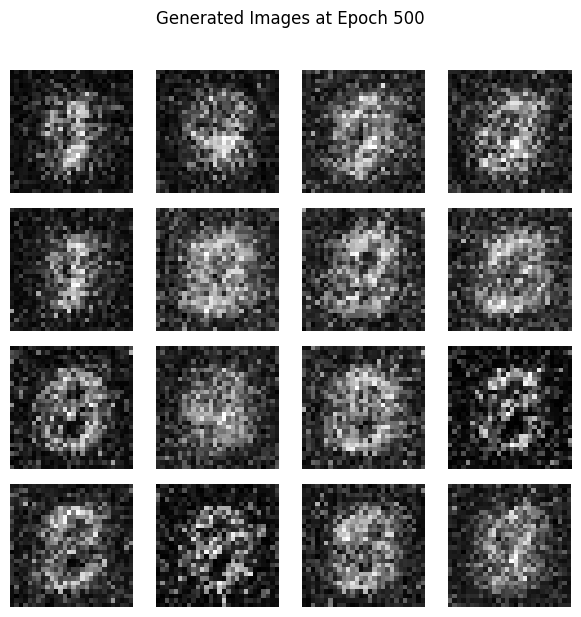

Epoch 600/3000  [D loss: 0.3793, acc.: 74.27%]  [G loss: 2.7182]
Epoch 700/3000  [D loss: 0.4127, acc.: 72.91%]  [G loss: 2.4392]
Epoch 800/3000  [D loss: 0.4366, acc.: 72.28%]  [G loss: 2.2367]
Epoch 900/3000  [D loss: 0.4563, acc.: 71.60%]  [G loss: 2.0792]
Epoch 1000/3000  [D loss: 0.4717, acc.: 71.18%]  [G loss: 1.9532]


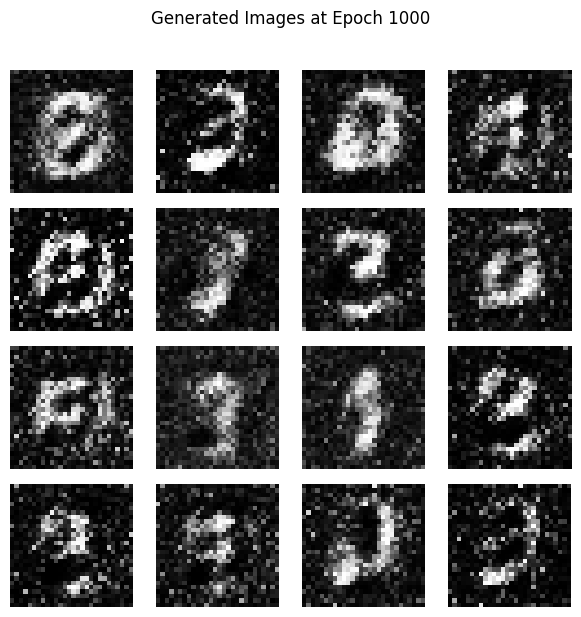

Epoch 1100/3000  [D loss: 0.4847, acc.: 70.78%]  [G loss: 1.8531]
Epoch 1200/3000  [D loss: 0.4945, acc.: 70.58%]  [G loss: 1.7721]
Epoch 1300/3000  [D loss: 0.5021, acc.: 70.50%]  [G loss: 1.7066]
Epoch 1400/3000  [D loss: 0.5093, acc.: 70.38%]  [G loss: 1.6492]
Epoch 1500/3000  [D loss: 0.5149, acc.: 70.30%]  [G loss: 1.6006]


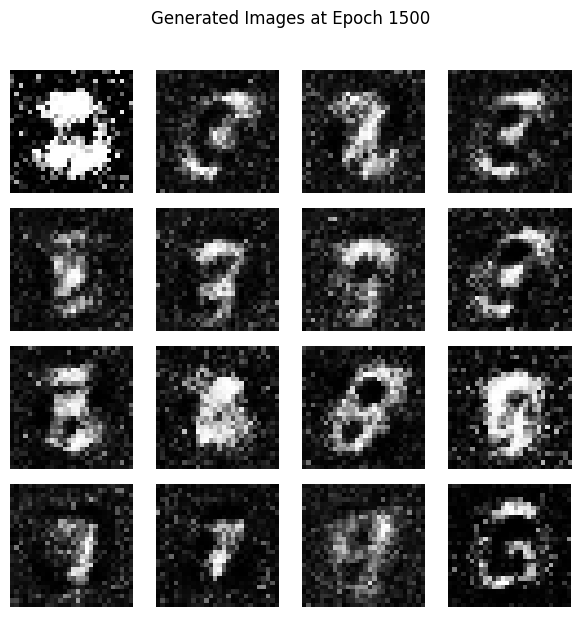

Epoch 1600/3000  [D loss: 0.5195, acc.: 70.24%]  [G loss: 1.5591]
Epoch 1700/3000  [D loss: 0.5237, acc.: 70.19%]  [G loss: 1.5229]
Epoch 1800/3000  [D loss: 0.5274, acc.: 70.14%]  [G loss: 1.4912]
Epoch 1900/3000  [D loss: 0.5305, acc.: 70.09%]  [G loss: 1.4629]
Epoch 2000/3000  [D loss: 0.5326, acc.: 70.13%]  [G loss: 1.4392]


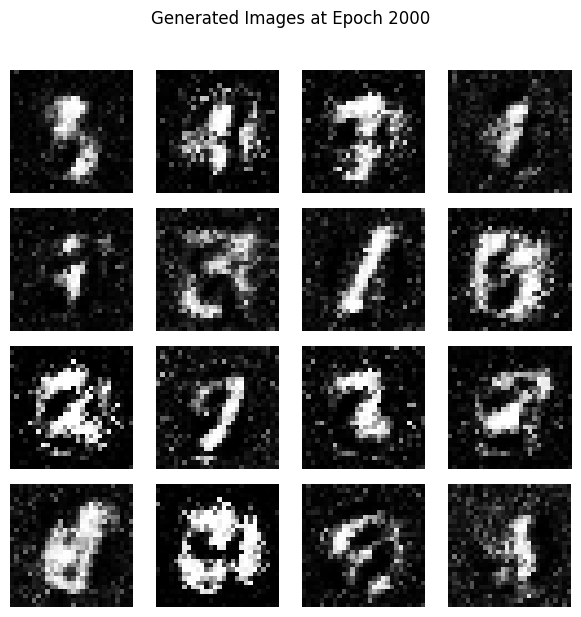

Epoch 2100/3000  [D loss: 0.5345, acc.: 70.18%]  [G loss: 1.4188]
Epoch 2200/3000  [D loss: 0.5363, acc.: 70.19%]  [G loss: 1.4003]
Epoch 2300/3000  [D loss: 0.5386, acc.: 70.14%]  [G loss: 1.3825]
Epoch 2400/3000  [D loss: 0.5403, acc.: 70.12%]  [G loss: 1.3669]
Epoch 2500/3000  [D loss: 0.5425, acc.: 70.05%]  [G loss: 1.3517]


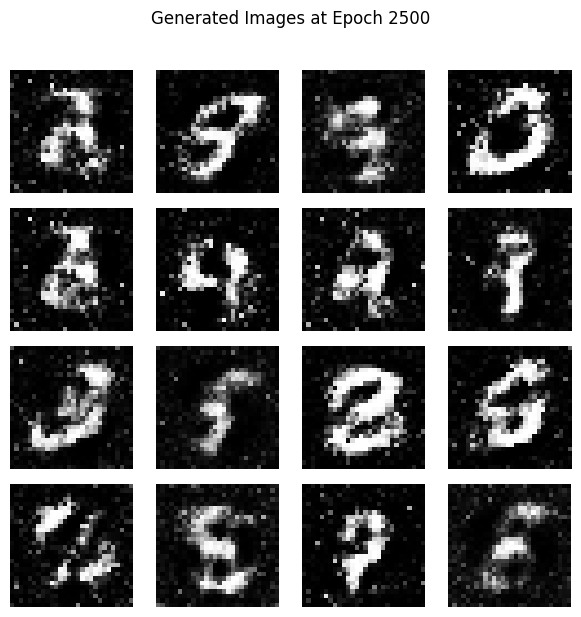

Epoch 2600/3000  [D loss: 0.5447, acc.: 69.96%]  [G loss: 1.3369]
Epoch 2700/3000  [D loss: 0.5469, acc.: 69.86%]  [G loss: 1.3229]
Epoch 2800/3000  [D loss: 0.5491, acc.: 69.74%]  [G loss: 1.3097]
Epoch 2900/3000  [D loss: 0.5512, acc.: 69.63%]  [G loss: 1.2973]
Epoch 3000/3000  [D loss: 0.5535, acc.: 69.50%]  [G loss: 1.2855]


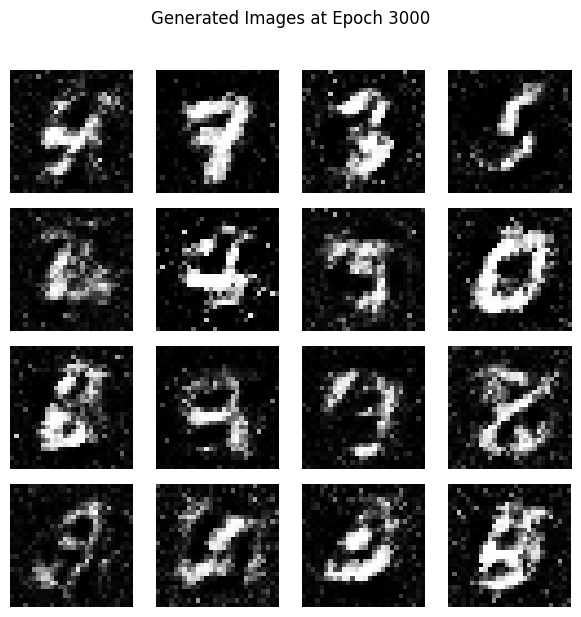

In [12]:
d_losses = []
g_losses = []

valid = np.ones((batch_size, 1))
fake = np.zeros((batch_size, 1))

for epoch in range(1, epochs + 1):
    # ---------------------
    #  Train Discriminator
    # ---------------------
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    gen_imgs = generator.predict(noise, verbose=0)

    discriminator.trainable = True
    d_loss_real = discriminator.train_on_batch(real_imgs, valid)
    d_loss_fake = discriminator.train_on_batch(gen_imgs, fake)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # -----------------
    #  Train Generator
    # -----------------
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    discriminator.trainable = False
    g_loss = gan.train_on_batch(noise, valid)

    d_losses.append(float(d_loss[0]))
    g_losses.append(float(g_loss))

    if epoch % 100 == 0:
        print(f"Epoch {epoch}/{epochs}  [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.2f}%]  [G loss: {float(g_loss):.4f}]")

    if epoch % sample_interval == 0:
        plot_generated_images(epoch, generator, latent_dim)

## 10. Plot Generator and Discriminator Loss


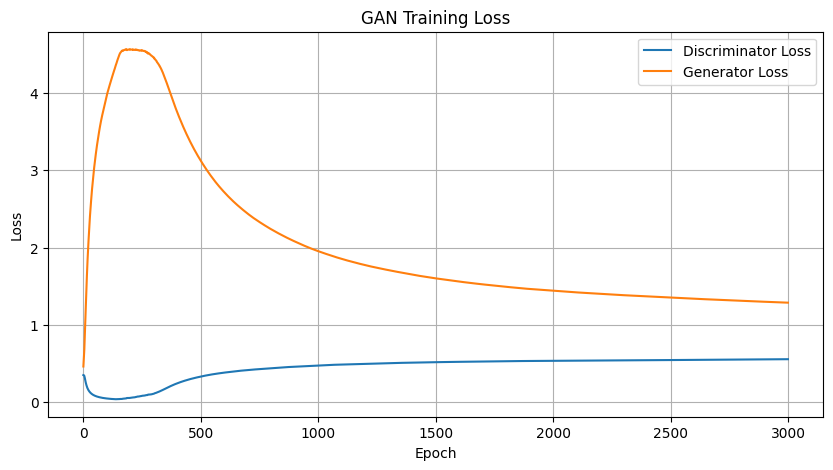

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Loss')
plt.legend()
plt.grid(True)
plt.show()

## 11. Generate Final Handwritten Digit Images


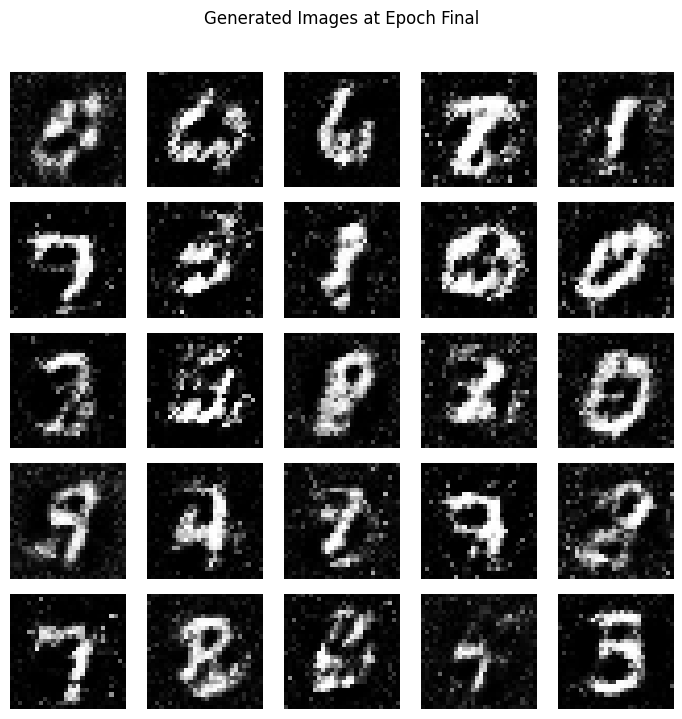

In [14]:
plot_generated_images('Final', generator, latent_dim, examples=25, dim=(5, 5), figsize=(7, 7))

## 12. Conclusion

In this experiment, we built and trained a GAN on the MNIST dataset to generate handwritten digits. The generator learned to create images from random noise, while the discriminator learned to classify real and fake images. After training, the GAN was able to produce digit-like images that resemble handwritten digits.
